In [5]:
from Analysis.systems import kitaev_chain,kramers_chain,kitaev_chain_spinful

import FockSystem.FockSystem as fst
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import time

In [6]:
from IPython.core.display import Markdown
from IPython.display import display

In [7]:
import Analysis.systems as kt

## Normal Lanczos

In [8]:
def make_alpha(positions_array, v0):
    heap = list(positions_array) ## probably good idea to make the heap smaller? some considerations for later
    length = len(v0)
    row_position = heap[0][0]

    alpha = 0
    row_v_i_out = 0
    ## Redundant step but had a hard time working out the logic for the starting config of the heap
    ## Needs to be fixed later
    for idx in range(len(heap)):
        retrieve_next(heap[idx])
    
    while(len(heap)>0):       
        curr_eval = heap[0]
        cur_i = curr_eval[0]
        cur_j = curr_eval[1]
        cur_val = curr_eval[-1]

        if cur_i != row_position:
            alpha += row_v_i_out ## alpha += A[i,j][v[j]*v[i]
            row_position = cur_i ## move row indicator
            row_v_i_out = 0 ## reset row-sum value storage
       
        row_v_i_out += cur_val*v0[cur_j]*v0[row_position]

        
        ## Evluate the heap
        retrieve_next(heap[0])
        if heap[0][0]>=length or heap[0][1]>=length or heap[0][5]>heap[0][7]:
            heap.pop(0)
        else:
            row=heap.pop(0)
            ## Insert into the correct position in the heap
            for i in range(len(heap)):
                if row[0] < heap[i][0]:
                    heap.insert(i,row)
                    break
                elif i == len(heap)-1:
                    heap.append(row)
    alpha+=row_v_i_out 
    return alpha

In [9]:
def test_sequence(start_i, start_j, small_rep,big_rep, big_rep_spacing):
    seq =[]
    for i in range(big_rep):
        for j in range(small_rep):
            i_val = start_i + i * big_rep_spacing + j
            j_val = start_j + i * big_rep_spacing + j
            seq.append([i_val,j_val])
    print(seq)

In [10]:

def random_unit_vector(n):
    vec = np.random.randn(n)  # Draw from standard normal distribution
    return vec / np.linalg.norm(vec)  # Normalize to unit norm

# Example: 5-dimensional unit vector
v = random_unit_vector(5)
print(v)
print("Norm:", np.linalg.norm(v))

[ 0.24813417  0.59539419 -0.44076771 -0.03380921 -0.62331048]
Norm: 1.0


In [11]:
def lanczos(arr,v_1, n_iters = 10, ):
    n= np.shape(arr)[0]
    krylov_space_array = np.zeros((n_iters,n_iters))

    w_prime = arr @ v_1
    alpha_1 = np.transpose(w_prime)@v_1

    
    w_1 = w_prime - alpha_1*v_1

    krylov_space_array[0][0] = alpha_1
    krylov_space_array[0][1] = np.linalg.norm(w_1)
    krylov_space_array[1][0] = np.linalg.norm(w_1)

    for i in range(1,n_iters):
        if i==1:
            w_i_minus = w_1
            v_i_minus = v_1
        else:
            w_i_minus = w_i
            v_i_minus = v_i
        
        B_i = krylov_space_array[i-1,i]
        if krylov_space_array[i-1,i] != 0:
            v_i = w_i_minus/B_i
        else:
            print("Panick")

        w_i_prime = arr @ v_i - B_i*v_i_minus
        alpha_i = np.transpose(w_i_prime)@v_i
        w_i = w_i_prime - alpha_i*v_i
        
        krylov_space_array[i][i] = alpha_i
        
        if i != len(krylov_space_array)-1:
            krylov_space_array[i][i+1] = np.linalg.norm(w_i)
            krylov_space_array[i+1][i] = np.linalg.norm(w_i)

    return krylov_space_array

In [12]:
def add_conjugate_and_sort(sparse_matr, vals):
    only_indices = sparse_matr[:,:2]
    result_arr=[]
    result_vals=[]
    for enum,index_pair in enumerate(only_indices):
        if index_pair[0] == index_pair[1]:
            
            result_arr.append([index_pair[0],index_pair[1],index_pair[0],index_pair[1], 0,0, sparse_matr[enum][2],sparse_matr[enum][3],sparse_matr[enum][4], vals[enum]*2])
        else:
            result_arr.append([index_pair[0],index_pair[1],index_pair[0],index_pair[1], 0,0, sparse_matr[enum][2],sparse_matr[enum][3],sparse_matr[enum][4], vals[enum]])

            result_arr.append([index_pair[1],index_pair[0],index_pair[1],index_pair[0], 0,0, sparse_matr[enum][2],sparse_matr[enum][3],sparse_matr[enum][4], vals[enum]])
          

    result_arr=np.array(result_arr)
    sorted_indices = result_arr[:,0].argsort()
    sorted_arr = result_arr[sorted_indices]
    
    return sorted_arr.astype(int).tolist()

In [13]:
### TESTING CODE FOR MAKING SURE THE SEQUENCE EVALUATOR WORKS

#heap_data = add_conjugate_and_sort(sparsest_matr,sparest_vals)
#for t in range(len(heap_data)):
#    retrieve_next(heap_data[t])
#for idx in range(len(heap_data)):
    # print(idx)
    # h = heap_data[idx]
    # test_sequence(h[0],h[1], h[6],h[7],h[8])

    # seq = []
    
    # for _ in range(10):
    #     seq.append([heap_data[idx][0],heap_data[idx][1]])
    #     retrieve_next(heap_data[idx])
    #     if heap_data[idx][0] >= len(arr) or heap_data[idx][1]>=len(arr) or (heap_data[idx][5]>heap_data[idx][7]):
    #         break
        
       
    # print(seq)
    # print("_____")

In [14]:
def retrieve_next(heap_list):
    ## Given a heap-row, progress it to its next value
    heap_list[0] = heap_list[2] + heap_list[4] + heap_list[5]*heap_list[8]
    heap_list[1] = heap_list[3] + heap_list[4] + heap_list[5]*heap_list[8]

    heap_list[4] += 1
    
    if heap_list[4] >= heap_list[6]:
        heap_list[4] = 0
        heap_list[5] += 1

In [15]:
def evaluate_row(heap,v0):
    row_v_i_out = 0
    row_result = 0
    row_position = heap[0][0] ## Determine at what row we are
    length = len(v0)
    while(len(heap)>0):       
        curr_eval = heap[0]
        cur_i = curr_eval[0]
        cur_j = curr_eval[1]
        cur_val = curr_eval[-1]
        
        if cur_i != row_position:
            row_result += row_v_i_out 
            return row_result
        
        row_v_i_out += cur_val*v0[cur_j] ## A@v
        
        ## Progress the heap
        retrieve_next(heap[0])

        ## Check whether it has gone out of bounds or reached the end of its line
        if heap[0][0]>=length or heap[0][1]>=length or heap[0][5]>heap[0][7]:
            heap.pop(0)
        ## Otherwise, move it to the new correct position
        else:
            row=heap.pop(0)
            ## Insert into the correct position in the heap
            for i in range(len(heap)):
                if row[0] < heap[i][0]:
                    heap.insert(i,row)
                    break
                elif i == len(heap)-1:
                    heap.append(row)
    row_result += row_v_i_out
    return row_result

In [16]:
from copy import deepcopy

In [17]:
def sparse_lanczos(start_heap, v0, n_iters = 3):
    krylov_space = np.zeros((n_iters,n_iters))

    ## put the heap in correct state 
    ## (could I progress the entire heap at once? it should be linearized actually.
    ## Probably best to do this upon creation)
    for idx in range(len(start_heap)):
        retrieve_next(start_heap[idx])

    ###########################
    ## Initialise the system ##
    ###########################
    heap = deepcopy(start_heap)
    while(len(heap)>0):
        current_row = heap[0][0]
        row_result = evaluate_row(heap,v0)
        krylov_space[0][0] += row_result*v0[current_row]

    heap = deepcopy(start_heap)
    while(len(heap)>0):
        current_row = heap[0][0]
        row_result = evaluate_row(heap,v0)
        krylov_space[0][1] += (row_result - krylov_space[0][0]*v0[current_row])**2
    krylov_space[0][1] = np.sqrt(krylov_space[0][1])
    krylov_space[1][0] = krylov_space[0][1]

    ###########################
    ## Start next iterations ##
    ###########################
    heap = deepcopy(start_heap)
   

    
    print(krylov_space)

In [18]:
def get_alpha_row_wise(heap,v0):
    alpha = 0
    for idx in range(len(heap)):
        retrieve_next(heap[idx])
    while(len(heap)>0):
        current_row = heap[0][0]
        row_result = evaluate_row(heap,v0)
        alpha+= row_result*v0[current_row]

    return alpha

In [19]:
random_v = random_unit_vector(len(arr))
#random_v = np.ones(len(arr))

NameError: name 'arr' is not defined

In [37]:
t = H**2

In [ ]:
heap_data = add_conjugate_and_sort(sparsest_matr,sparest_vals)
get_alpha_row_wise(heap_data, random_v)

In [ ]:

heap_data = add_conjugate_and_sort(H[sparse_basis].rc_indices,H[sparse_basis].values)
krylov = sparse_lanczos(heap_data,random_v,n_iters= 3)

In [ ]:
krylov = lanczos(arr,random_v,n_iters= 3)
np.linalg.eigh(krylov,)[0][:3]
print(krylov)

In [ ]:
arr = H[normal_basis].to_array()

In [ ]:
v_1 = random_unit_vector(len(arr))

In [ ]:
w_prime = arr @ v_1
alpha_1 = np.transpose(w_prime)@v_1
w_1 = w_prime - alpha_1*v_1

In [ ]:
start_v = random_unit_vector(len(arr))

In [ ]:
N = 3
MU,U, ECT,CAR = kitaev_chain_spinful(N)
H = MU + CAR + ECT + U
H[MU] = 10
H[CAR] = 20
H[ECT] = -20
H[U] = 50
normal_basis = fst.FockStates(N)
sparse_basis = fst.FockStatesSparse(N)
arr = np.array(H[normal_basis].to_array(),dtype=np.int64)

In [ ]:
n_iters = 150
subspace = np.zeros((n_iters,n_iters))

for idx in range(n_iters):
    v_1 = random_unit_vector(len(arr))
    w_prime = arr @ v_1
    alpha_1 = np.transpose(w_prime)@v_1
    w_1 = w_prime - alpha_1*v_1
    subspace[idx][idx] = alpha_1
    if idx < n_iters-1:
        subspace[idx][idx+1] = np.linalg.norm(w_1)
        subspace[idx+1][idx] = np.linalg.norm(w_1)

In [ ]:
n_iters = 5
subspace = np.zeros((n_iters,n_iters))
store_vecs = []

for idx in range(n_iters):
    rand_vec = random_unit_vector(len(arr))
    store_vecs.append(rand_vec)

new_vecs = []
for idx_iter in range(n_iters):
    start_vec = store_vecs[idx_iter]
    new_vec = start_vec
    for dot_prod_iter in range(idx_iter):
        new_vec = new_vec - (start_vec @ store_vecs[dot_prod_iter])*store_vecs[dot_prod_iter]

    new_vecs.append(new_vec)

subspace = new_vecs @ arr @ np.transpose(new_vecs)
print(subspace)

In [ ]:
np.linalg.eigh(subspace)

In [ ]:
np.linalg.eigh(arr)

# Example

In [ ]:
from FockSystem.FockSystemSparse import FockStatesSparse

In [ ]:
plt.matshow(arr)

In [ ]:
fig,ax = plt.subplots(ncols = 2)
ax[0].matshow(A[:n//4,n//4:])
ax[0].matshow(A)

ax[1].matshow(B)

In [ ]:
plt.matshow(A)

In [ ]:
normal_basis = fst.FockStates(N)
sparse_basis = fst.FockStatesSparse(N)

In [ ]:
arr = np.array(H[normal_basis].to_array(),dtype=np.int64)

In [ ]:
n = np.shape(arr)[0]

A = np.array(arr[:n//2,:n//2], dtype=np.int64)
B = np.array(arr[:n//2,n//2:], dtype=np.int64)
C = np.array(arr[n//2:,:n//2,],dtype=np.int64)
D =  np.array(arr[n//2:,n//2:],dtype=np.int64)
schur = A- B @ np.linalg.inv(D) @ C

In [ ]:
fig,axs = plt.subplots(ncols=  3)
axs[0].matshow(arr)
axs[1].matshow(left_cuadr)
axs[2].matshow(right_cuadr)

# Test

In [ ]:
input_vector = np.array([np.random.randint(2) for _ in range(4**N)], dtype=np.float64)
comp = np.array(input_vector,dtype=complex)

In [ ]:
sparse_matr = H[normal_basis].to_sparse_csr()
%time sparse_matr @ input_vector

In [ ]:
test_sparse = H[sparse_basis] @ input_vector
test_normal = H[normal_basis] @ comp
np.all(test_sparse==test_normal)

In [4]:
build_normal_times = []
matvec_normal_times = []
memory_normal = []

build_sparse_times = []
matvec_sparse_times = []
memory_sparse = []

### Test Sparse build
N_range_sparse = np.arange(2,20)
print("Testing sparse build")

for n in N_range_sparse:
    print(n)
    ### Make H
    MU,U, ECT,CAR = kitaev_chain_spinful(n)
    H = MU + CAR + ECT + U
    H[MU] = 10
    H[CAR] = 25
    H[ECT] = 13
    H[U] = 8

    ### Test Normal and Sparse
    summed_constr = 0
    repeated_constr = 5
    for _ in range(repeated_constr):
        ### CONSTRUCTION
        sparse_basis = fst.FockStatesSparse(int(n))
        start = time.perf_counter()
        sparse_construct = H[sparse_basis]
        end = time.perf_counter()
        summed_constr += (end-start)        
        del sparse_basis
    memory_sparse.append(sparse_construct.rc_indices.nbytes)
    del sparse_construct
    build_sparse_times.append(summed_constr/repeated_constr)

### Test Sparse MATRIX - VECTOR
N_range_sparse_mv = np.arange(2,12)
print("Testing sparse matvec")
for n in N_range_sparse_mv:
    print(n)

    ### Make H
    MU,U, ECT,CAR = kitaev_chain_spinful(n)
    H = MU + CAR + ECT + U
    H[MU] = 10
    H[CAR] = 25
    H[ECT] = 13
    H[U] = 8
    sparse_basis = fst.FockStatesSparse(int(n))
    sparse_construct = H[sparse_basis]

    ### Test Normal and Sparse
    summed_constr = 0
    repeated_constr = 5
    for _ in range(repeated_constr):
        test_vector = np.array([np.random.randint(2) for _ in range(4**n)], dtype=np.float64)
        ### CONSTRUCTION
        start = time.perf_counter()
        res = sparse_construct @ test_vector
        end = time.perf_counter()
        summed_constr += (end-start)        
        del test_vector
        del res
    del sparse_basis
    del sparse_construct
    matvec_sparse_times.append(summed_constr/repeated_constr)

### Test Normal build
N_range_normal = np.arange(2,11)
print("Testing normal build")
for n in N_range_normal:
    print(n)
    ### Make H
    MU,U, ECT,CAR = kitaev_chain_spinful(n)
    H = MU + CAR + ECT + U
    H[MU] = 10
    H[CAR] = 25
    H[ECT] = 13
    H[U] = 8

    ### Test Normal
    summed = 0
    if n < 5:
        repeated = 5
    else:
        repeated = 1
    for _ in range(repeated):
        normal_basis = fst.FockStates(int(n))
        start = time.perf_counter()
        normal_construct = H[normal_basis]
        end = time.perf_counter()
        summed += (end-start)
        del normal_basis
        del normal_construct
    build_normal_times.append(summed/repeated)


### Test Normal  MATRIX - VECTOR
N_range_normal_mv = np.arange(2,11)
print("Testing normal matvec")
for n in N_range_normal_mv:
    print(n)
    ### Make H
    MU,U, ECT,CAR = kitaev_chain_spinful(n)
    H = MU + CAR + ECT + U
    H[MU] = 10
    H[CAR] = 25
    H[ECT] = 13
    H[U] = 8
    normal_basis = fst.FockStates(int(n))
    normal_construct = H[normal_basis]

    ### Test Normal
    summed = 0
    if n < 8:
        repeated = 5
    else:
        repeated = 1
    for _ in range(repeated):
        csr_matr = normal_construct.to_sparse_csr()
        memory_csr = csr_matr.data.nbytes + csr_matr.indices.nbytes + csr_matr.indptr.nbytes
        memory_normal.append(memory_csr)
        test_vector = np.array([np.random.randint(2) for _ in range(4**n)],  dtype=np.float64)
        
        start = time.perf_counter()
        res = csr_matr @ test_vector
        end = time.perf_counter()
        
        summed += (end-start)
        del csr_matr
        del test_vector
        del res
    
        
    del normal_basis
    del normal_construct
    matvec_normal_times.append(summed/repeated)


Testing sparse build
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
Testing sparse matvec
2
3
4
5
6
7
8
9
10
11
Testing normal build
2
3
4
5
6
7
8
9
10
Testing normal matvec
2
3
4
5
6
7
8
9
10


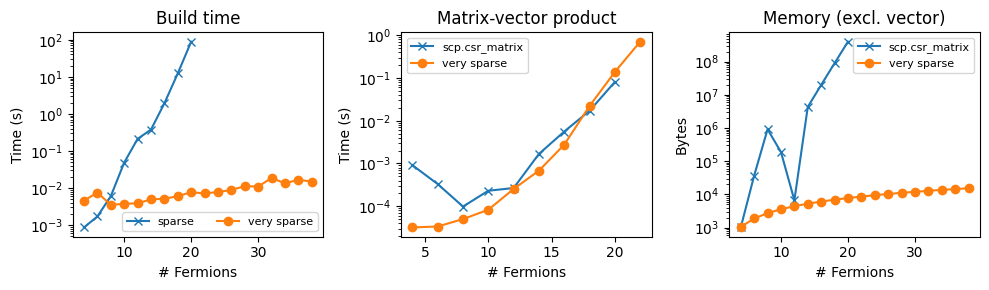

In [6]:
fig,axs = plt.subplots(ncols = 3, figsize=(10,3))

### Build Time
axs[0].set_yscale('log')
axs[0].plot(N_range_normal*2,build_normal_times, label = 'sparse', marker='x')
axs[0].plot(N_range_sparse*2, build_sparse_times, label = 'very sparse', marker='o')

axs[0].set_xlabel('# Fermions')
axs[0].set_ylabel('Time (s)')
axs[0].legend(loc='lower right',ncols=2,fontsize=8)
axs[0].set_title('Build time')

### Matrix - vector product
axs[1].set_yscale('log')
axs[1].set_ylabel('Time (s)')
axs[1].set_xlabel('# Fermions')

axs[1].plot(N_range_normal_mv*2, matvec_normal_times, label = 'scp.csr_matrix', marker='x')
axs[1].plot(N_range_sparse_mv*2, matvec_sparse_times, label = 'very sparse', marker='o')
axs[1].set_title('Matrix-vector product')
axs[1].legend(loc='upper left',ncols=1,fontsize=8)

### Memory requirement (excl. vector)
axs[2].set_yscale('log')
axs[2].set_title('Memory (excl. vector)')

axs[2].plot(N_range_normal_mv*2, list(set(memory_normal)), label = 'scp.csr_matrix', marker='x')
axs[2].plot(N_range_sparse*2, memory_sparse, label = 'very sparse', marker='o')
axs[2].legend(loc='upper right',ncols=1,fontsize=8)
axs[2].set_ylabel('Bytes')
axs[2].set_xlabel('# Fermions')
plt.tight_layout()

## Visualise

In [ ]:
def print_md(item):
    display(Markdown(item._repr_markdown_()))

In [ ]:
## Build the Hamiltonian
fig,axs = plt.subplots(ncols=4,figsize = (14,5))

for idx,N in enumerate(range(2,6)):
    ## Build the Hamiltonian
    MU,CAR,ECT = kitaev_chain(N)
    H = MU + CAR +ECT
    H[MU] = 1
    H[CAR] = 5
    H[ECT] = 2

    
    axs[idx].matshow(np.real(H[basis].to_array()))

plt.tight_layout()

In [20]:
MU,U, ECT,CAR = kitaev_chain_spinful(5)
H = MU + CAR + ECT + U

In [33]:
H**

 $c^{†}_{0,↓}$$c_{0,↓}$ $+$ $c^{†}_{0,↑}$$c_{0,↑}$ $+$ $c^{†}_{1,↓}$$c_{1,↓}$ $+$ $c^{†}_{1,↑}$$c_{1,↑}$ $+$ $c^{†}_{2,↓}$$c_{2,↓}$ $+$ $c^{†}_{2,↑}$$c_{2,↑}$ $+$ $c^{†}_{3,↓}$$c_{3,↓}$ $+$ $c^{†}_{3,↑}$$c_{3,↑}$ $+$ $c^{†}_{4,↓}$$c_{4,↓}$ $+$ $c^{†}_{4,↑}$$c_{4,↑}$ $-$ $c_{0,↑}$$c_{1,↓}$ $+$ $c_{0,↓}$$c_{1,↑}$ $-$ $c_{1,↑}$$c_{2,↓}$ $+$ $c_{1,↓}$$c_{2,↑}$ $-$ $c_{2,↑}$$c_{3,↓}$ $+$ $c_{2,↓}$$c_{3,↑}$ $-$ $c_{3,↑}$$c_{4,↓}$ $+$ $c_{3,↓}$$c_{4,↑}$ $+$ $c^{†}_{0,↓}$$c_{1,↓}$ $+$ $c^{†}_{0,↑}$$c_{1,↑}$ $+$ $c^{†}_{1,↓}$$c_{2,↓}$ $+$ $c^{†}_{1,↑}$$c_{2,↑}$ $+$ $c^{†}_{2,↓}$$c_{3,↓}$ $+$ $c^{†}_{2,↑}$$c_{3,↑}$ $+$ $c^{†}_{3,↓}$$c_{4,↓}$ $+$ $c^{†}_{3,↑}$$c_{4,↑}$ $+$ $c^{†}_{0,↓}$$c^{†}_{0,↑}$$c_{0,↓}$$c_{0,↑}$ $+$ $c^{†}_{1,↓}$$c^{†}_{1,↑}$$c_{1,↓}$$c_{1,↑}$ $+$ $c^{†}_{2,↓}$$c^{†}_{2,↑}$$c_{2,↓}$$c_{2,↑}$ $+$ $c^{†}_{3,↓}$$c^{†}_{3,↑}$$c_{3,↓}$$c_{3,↑}$ $+$ $c^{†}_{4,↓}$$c^{†}_{4,↑}$$c_{4,↓}$$c_{4,↑}$

In [32]:
%time a = H**4

CPU times: total: 1.3 s
Wall time: 1.29 s


In [ ]:
n = 5
MU,U, ECT,CAR = kitaev_chain_spinful(n)
H = MU + CAR + ECT + U
H[MU] = 10
H[CAR] = 25
H[ECT] = 13
H[U] = 8
normal_basis = fst.FockStates(int(n))
normal_construct = H[normal_basis]

In [ ]:
sparse_basis = fst.FockStatesSparse(int(n))


In [ ]:
sparse_csr = H[normal_basis].to_sparse_csr()

In [ ]:
rand_vec = random_unit_vector(4**n)

In [ ]:
test_sparse = H[sparse_basis] @rand_vec

In [ ]:
test_nomral = H[normal_basis] @rand_vec

In [ ]:
test_sparse

In [ ]:
test_nomral = sparse_csr @ rand_vec

In [ ]:
H[normal_basis

In [ ]:
np.allclose(test_nomral==test_sparse)

In [7]:
build_normal_times = []
matvec_normal_times = []
memory_normal = []

build_sparse_times = []
matvec_sparse_times = []
memory_sparse = []

### Test Sparse build
N_range_sparse = np.arange(2,20)
print("Testing sparse build")

for n in N_range_sparse:
    print(n)
    ### Make H
    MU,U, ECT,CAR = kitaev_chain_spinful(n)
    H = MU + CAR + ECT + U
    H[MU] = 10
    H[CAR] = 25
    H[ECT] = 13
    H[U] = 8

    ### Test Normal and Sparse
    summed_constr = 0
    repeated_constr = 5

    for _ in range(repeated_constr):
        ### CONSTRUCTION
        sparse_basis = fst.FockStatesSparse(int(n))
        start = time.perf_counter()
        sparse_construct = H[sparse_basis]
        end = time.perf_counter()
        summed_constr += (end-start)        
        del sparse_basis
    memory_sparse.append(sparse_construct.rc_indices.nbytes)
    del sparse_construct
    build_sparse_times.append(summed_constr/repeated_constr)

### Test Sparse MATRIX - VECTOR
N_range_sparse_mv = np.arange(2,13)
print("Testing sparse matvec")

for n in N_range_sparse_mv:
    print(n)

    ### Make H
    MU,U, ECT,CAR = kitaev_chain_spinful(n)
    H = MU + CAR + ECT + U
    H[MU] = 10
    H[CAR] = 25
    H[ECT] = 13
    H[U] = 8
    sparse_basis = fst.FockStatesSparse(int(n))
    sparse_construct = H[sparse_basis]

    ### Test Normal and Sparse
    summed_constr = 0
    repeated_constr = 4
    for _ in range(repeated_constr):
        test_vector = np.array([np.random.randint(2) for _ in range(4**n)], dtype=np.float64)
        ### CONSTRUCTION
        start = time.perf_counter()
        res = sparse_construct @ test_vector
        end = time.perf_counter()
        summed_constr += (end-start)        
        del test_vector
        del res
    del sparse_basis
    del sparse_construct
    matvec_sparse_times.append(summed_constr/repeated_constr)

### Test Normal build
N_range_normal = np.arange(2,11)
print("Testing normal build")
for n in N_range_normal:
    print(n)
    ### Make H
    MU,U, ECT,CAR = kitaev_chain_spinful(n)
    H = MU + CAR + ECT + U
    H[MU] = 10
    H[CAR] = 25
    H[ECT] = 13
    H[U] = 8

    ### Test Normal
    summed = 0
    if n < 5:
        repeated = 1
    else:
        repeated = 1
    for _ in range(repeated):
        normal_basis = fst.FockStates(int(n))
        start = time.perf_counter()
        normal_construct = H[normal_basis]
        end = time.perf_counter()
        summed += (end-start)
        del normal_basis
        del normal_construct
    build_normal_times.append(summed/repeated)


### Test Normal  MATRIX - VECTOR
N_range_normal_mv = np.arange(2,11)
print("Testing normal matvec")
for n in N_range_normal_mv:
    print(n)
    ### Make H
    MU,U, ECT,CAR = kitaev_chain_spinful(n)
    H = MU + CAR + ECT + U
    H[MU] = 10
    H[CAR] = 25
    H[ECT] = 13
    H[U] = 8
    normal_basis = fst.FockStates(int(n))
    normal_construct = H[normal_basis]

    ### Test Normal
    summed = 0
    repeated = 3
    csr_matr = normal_construct.to_sparse_csr()
    memory_csr = csr_matr.data.nbytes + csr_matr.indices.nbytes + csr_matr.indptr.nbytes
    memory_normal.append(memory_csr)
    for _ in range(repeated):
        csr_matr = normal_construct.to_sparse_csr()
        test_vector = np.array([np.random.randint(2) for _ in range(4**n)],  dtype=np.float64)
        
        start = time.perf_counter()
        res = csr_matr @ test_vector
        end = time.perf_counter()
        
        summed += (end-start)
        del csr_matr
        del test_vector
        del res
    
        
    del normal_basis
    del normal_construct
    matvec_normal_times.append(summed/repeated)


Testing sparse build
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
Testing sparse matvec
2
3
4
5
6
7
8
9
10
11
12
Testing normal build
2
3
4
5
6
7
8
9
10
Testing normal matvec
2
3
4
5
6
7
8
9
10


In [16]:
import ultraplot as pplt

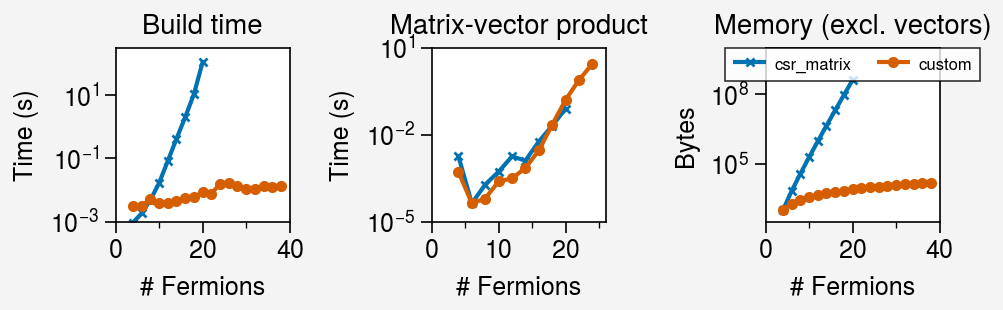

In [53]:
fig,axs = pplt.subplots(ncols = 3, figwidth = 5.01968504,sharex=False,sharey=False,grid='off')
### Build Time
axs[0].set_yscale('log')
axs[0].plot(N_range_normal*2,build_normal_times, label = 'sparse', marker='x',markersize=3)
axs[0].plot(N_range_sparse*2, build_sparse_times, label = 'memory optimized', marker='o',markersize=3)

axs[0].set_xlabel('# Fermions')
axs[0].set_ylabel('Time (s)')
#axs[0].legend(loc='lower right',ncols=1,fontsize=7)
axs[0].set_title('Build time')

### Matrix - vector product
axs[1].set_yscale('log')
axs[1].set_ylabel('Time (s)')
axs[1].set_xlabel('# Fermions')

axs[1].plot(N_range_normal_mv*2, matvec_normal_times, label = 'scp.csr_matrix', marker='x',markersize=3)
axs[1].plot(N_range_sparse_mv*2, matvec_sparse_times, label = 'memory optimized', marker='o',markersize=3)
axs[1].set_title('Matrix-vector product')
#axs[1].legend(loc='upper left',ncols=1,fontsize=7)

### Memory requirement (excl. vector)
axs[2].set_yscale('log')
axs[2].set_title('Memory (excl. vectors)')

axs[2].plot(N_range_normal_mv*2, memory_normal, label = 'csr_matrix', marker='x',markersize=3)
axs[2].plot(N_range_sparse*2, memory_sparse, label = 'custom', marker='o',markersize=3)
axs[2].legend(loc='upper center',ncols=2,fontsize=6)
axs[2].set_ylabel('Bytes')
axs[2].set_xlabel('# Fermions')
axs[0].format(xlim = [0,40],yformatter='log',ylim = [10**-3,10**2.5])
axs[1].format(xlim = [0,26],yformatter='log', ylim = [10**-5,10**1])
axs[2].format(xlim = [0,40],yformatter='log', ylim = [10**2.5,10**10])
axs[0].format(xminorlocator=10,xlocator=20)
axs[2].format(xminorlocator=10,xlocator=20)
axs[1].format(xminorlocator=5,xlocator=10)
fig.savefig('./appendix_A.png')


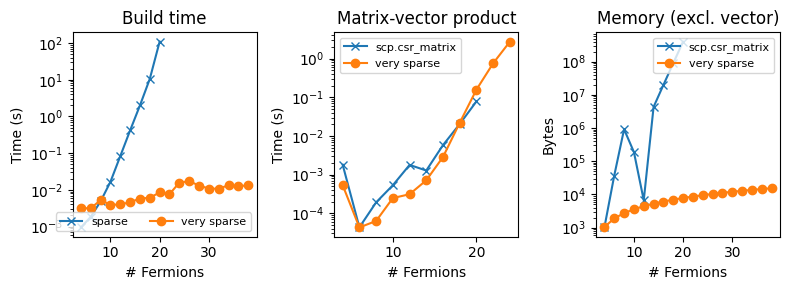

In [13]:
fig,axs = plt.subplots(ncols = 3,figsize=( 8, 3))

### Build Time
axs[0].set_yscale('log')
axs[0].plot(N_range_normal*2,build_normal_times, label = 'sparse', marker='x')
axs[0].plot(N_range_sparse*2, build_sparse_times, label = 'very sparse', marker='o')

axs[0].set_xlabel('# Fermions')
axs[0].set_ylabel('Time (s)')
axs[0].legend(loc='lower right',ncols=2,fontsize=8)
axs[0].set_title('Build time')

### Matrix - vector product
axs[1].set_yscale('log')
axs[1].set_ylabel('Time (s)')
axs[1].set_xlabel('# Fermions')

axs[1].plot(N_range_normal_mv*2, matvec_normal_times, label = 'scp.csr_matrix', marker='x')
axs[1].plot(N_range_sparse_mv*2, matvec_sparse_times, label = 'very sparse', marker='o')
axs[1].set_title('Matrix-vector product')
axs[1].legend(loc='upper left',ncols=1,fontsize=8)

### Memory requirement (excl. vector)
axs[2].set_yscale('log')
axs[2].set_title('Memory (excl. vector)')

axs[2].plot(N_range_normal_mv*2, list(set(memory_normal)), label = 'scp.csr_matrix', marker='x')
axs[2].plot(N_range_sparse*2, memory_sparse, label = 'very sparse', marker='o')
axs[2].legend(loc='upper right',ncols=1,fontsize=8)
axs[2].set_ylabel('Bytes')
axs[2].set_xlabel('# Fermions')
plt.tight_layout()